# ⚙️ Credit Scoring — Notebook 02: Hyperparameter Tuning (GridSearchCV)
**Author:** Abu Jafar Sisty  
**Conference:** COMPAS 2026 — IEEE, University of Dhaka  
**Dataset:** Give Me Some Credit — 150,000 records

In [1]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import json
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

SEED = 42
np.random.seed(SEED)

os.makedirs('../figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 1️⃣ Load, Clean & Feature Engineering
(Same as Notebook 01 — must be identical!)

In [3]:
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

# --- Cleaning ---
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
for col in ['DebtRatio', 'MonthlyIncome']:
    df[col] = df[col].clip(0, df[col].quantile(0.99))
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    df[col] = df[col].clip(0, 10)

# --- Feature Engineering ---
df['TotalTimesPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['WeightedLatePay'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df['NumberOfTimes90DaysLate'] * 3
)
df['MonthlyDebt']        = df['DebtRatio'] * df['MonthlyIncome']
df['NetMonthlyIncome']   = df['MonthlyIncome'] - df['MonthlyDebt']
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['DebtPerDependent']   = df['MonthlyDebt']   / (df['NumberOfDependents'] + 1)
df['HighUtilization']    = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.7).astype(int)
df['MaxedOut']           = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.95).astype(int)
df['IsYoung']            = (df['age'] < 30).astype(int)
df['IsSenior']           = (df['age'] > 60).astype(int)
df['AgeBucket']          = pd.cut(df['age'], bins=[0,25,35,45,55,65,100], labels=[0,1,2,3,4,5]).astype(int)
df['HasLatePay']         = (df['TotalTimesPastDue'] > 0).astype(int)
df['HasSeriousLatePay']  = (df['NumberOfTimes90DaysLate'] > 0).astype(int)
df['HasOpenLoans']       = (df['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df['HasRealEstate']      = (df['NumberRealEstateLoansOrLines'] > 0).astype(int)
df['IsNegativeCash']     = (df['NetMonthlyIncome'] < 0).astype(int)
df['UtilizationXLatePay'] = df['RevolvingUtilizationOfUnsecuredLines'] * df['TotalTimesPastDue']
df['DebtRatioXAge']      = df['DebtRatio'] * df['age']

# --- Split ---
target_col = 'SeriousDlqin2yrs'
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=SEED, stratify=y.values
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

scale_weight = (y.values == 0).sum() / (y.values == 1).sum()

print(f'✅ Dataset ready: {X_train.shape[0]:,} train, {X_test.shape[0]:,} test')
print(f'Total features  : {len(feature_names)}')
print(f'scale_pos_weight: {scale_weight:.2f}')

✅ Dataset ready: 119,988 train, 29,998 test
Total features  : 28
scale_pos_weight: 13.96


## 2️⃣ Load Baseline Results

In [4]:
baseline_df = pd.read_csv('../outputs/baseline_results.csv')
print('=== Baseline Results ===')
print(baseline_df.to_string(index=False))

=== Baseline Results ===
              Model    AUC  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting 0.8709    0.9375     0.9219  0.9375    0.9218
Logistic Regression 0.8678    0.7855     0.9301  0.7855    0.8361
            XGBoost 0.8503    0.8339     0.9252  0.8339    0.8680
      Random Forest 0.8427    0.9353     0.9169  0.9353    0.9185


## 3️⃣ Define Advanced Hyperparameter Grids

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_grids = {
    'Logistic Regression': {
        'C':      [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1', 'l2']
    },
    'Random Forest': {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators':  [200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth':     [3, 4, 5],
        'subsample':     [0.7, 0.8, 1.0],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators':     [300, 500, 700],
        'learning_rate':    [0.01, 0.05, 0.1],
        'max_depth':        [3, 4, 5, 6],
        'subsample':        [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'gamma':            [0, 0.1, 0.2]
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(
        random_state=SEED, max_iter=1000, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        random_state=SEED, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        random_state=SEED, eval_metric='logloss',
        verbosity=0, scale_pos_weight=scale_weight,
        n_jobs=-1, reg_alpha=0.1, reg_lambda=1.0
    )
}

print('✅ Grids defined!')
for name, grid in param_grids.items():
    combos = 1
    for v in grid.values(): combos *= len(v)
    print(f'   {name}: {combos} combinations × 5 folds')

✅ Grids defined!
   Logistic Regression: 24 combinations × 5 folds
   Random Forest: 72 combinations × 5 folds
   Gradient Boosting: 162 combinations × 5 folds
   XGBoost: 2916 combinations × 5 folds


## 4️⃣ GridSearchCV Tuning
⚠️ May take 30-60 minutes

In [6]:
tuned_results   = []
best_params_all = {}
tuned_models    = {}

for name, model in base_models.items():
    print(f'\n⚙️  Tuning: {name} ...')

    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_tr, y_train)

    best_model            = grid_search.best_estimator_
    tuned_models[name]    = best_model
    best_params_all[name] = grid_search.best_params_

    y_pred = best_model.predict(X_te)
    y_prob = best_model.predict_proba(X_te)[:, 1]

    tuned_results.append({
        'Model':       name,
        'AUC':         round(roc_auc_score(y_test, y_prob), 4),
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'Precision':   round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':      round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Best CV AUC': round(grid_search.best_score_, 4)
    })
    print(f'   ✅ AUC: {tuned_results[-1]["AUC"]:.4f} | Best params: {grid_search.best_params_}')

tuned_df = pd.DataFrame(tuned_results).sort_values('AUC', ascending=False)
tuned_df.to_csv('../outputs/tuned_results.csv', index=False)

print('\n===== TUNED RESULTS =====')
print(tuned_df.to_string(index=False))


⚙️  Tuning: Logistic Regression ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
   ✅ AUC: 0.8679 | Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

⚙️  Tuning: Random Forest ...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
   ✅ AUC: 0.8690 | Best params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 500}

⚙️  Tuning: Gradient Boosting ...
Fitting 5 folds for each of 162 candidates, totalling 810 fits
   ✅ AUC: 0.8719 | Best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.8}

⚙️  Tuning: XGBoost ...
Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
   ✅ AUC: 0.8728 | Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}

===== TUNED RESULTS =====
              Model    AUC  Accuracy  Precision  Recall  F1-Score  Best CV AUC
   

## 5️⃣ Save Best Model

In [7]:
best_model_name = tuned_df.iloc[0]['Model']
best_model_obj  = tuned_models[best_model_name]

with open('../models/best_credit_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)
with open('../models/best_params.pkl', 'wb') as f:
    pickle.dump(best_params_all, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(f'✅ Best model saved : {best_model_name}')
print(f'   AUC             : {tuned_df.iloc[0]["AUC"]}')
print('✅ Scaler & feature names saved!')

✅ Best model saved : XGBoost
   AUC             : 0.8728
✅ Scaler & feature names saved!


## 6️⃣ Baseline vs Tuned Comparison

In [8]:
comp   = baseline_df[['Model','AUC','Accuracy','F1-Score']].copy()
comp.columns = ['Model','Baseline AUC','Baseline Acc','Baseline F1']
tuned_c = tuned_df[['Model','AUC','Accuracy','F1-Score']].copy()
tuned_c.columns = ['Model','Tuned AUC','Tuned Acc','Tuned F1']

comparison = comp.merge(tuned_c, on='Model')
comparison['AUC Improvement (%)'] = (
    (comparison['Tuned AUC'] - comparison['Baseline AUC']) / comparison['Baseline AUC'] * 100
).round(2)
comparison = comparison.sort_values('Tuned AUC', ascending=False)
comparison.to_csv('../outputs/baseline_vs_tuned.csv', index=False)

print('===== BASELINE vs TUNED =====')
print(comparison.to_string(index=False))

===== BASELINE vs TUNED =====
              Model  Baseline AUC  Baseline Acc  Baseline F1  Tuned AUC  Tuned Acc  Tuned F1  AUC Improvement (%)
            XGBoost        0.8503        0.8339       0.8680     0.8728     0.7982    0.8449                 2.65
  Gradient Boosting        0.8709        0.9375       0.9218     0.8719     0.9374    0.9225                 0.11
      Random Forest        0.8427        0.9353       0.9185     0.8690     0.8373    0.8709                 3.12
Logistic Regression        0.8678        0.7855       0.8361     0.8679     0.7862    0.8366                 0.01


## 7️⃣ AUC Comparison Bar Chart

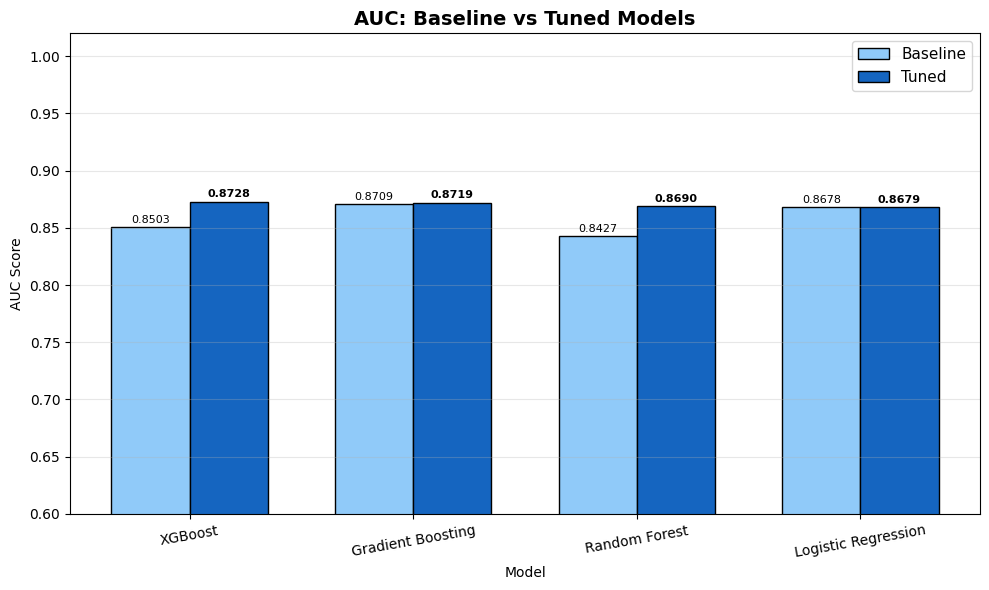

✅ Saved: figures/tuning_auc_comparison.png


In [9]:
x = np.arange(len(comparison['Model']))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, comparison['Baseline AUC'], width, label='Baseline', color='#90CAF9', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison['Tuned AUC'],    width, label='Tuned',    color='#1565C0', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=10, fontsize=10)
ax.set_ylim(0.6, 1.02)
ax.set_title('AUC: Baseline vs Tuned Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('AUC Score')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/tuning_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/tuning_auc_comparison.png')

## 8️⃣ Best Model — ROC Curve & Confusion Matrix

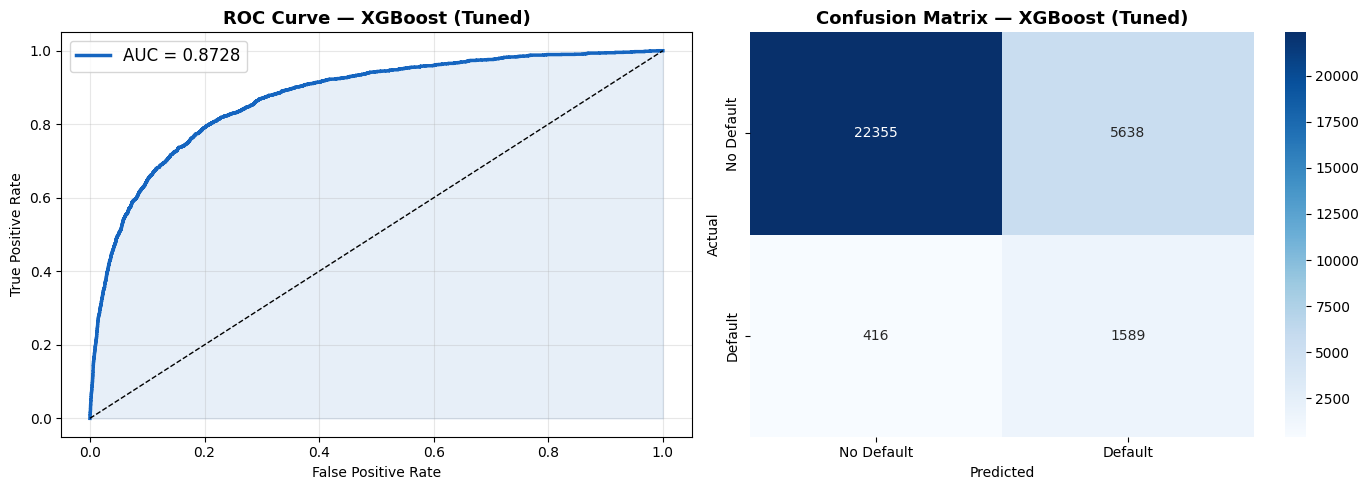

✅ Best Model AUC: 0.8728
✅ Saved: figures/best_model_roc_curve.png


In [10]:
best_name  = tuned_df.iloc[0]['Model']
best_model = tuned_models[best_name]
X_te_best  = X_test_scaled if best_name == 'Logistic Regression' else X_test

y_pred_best = best_model.predict(X_te_best)
y_prob_best = best_model.predict_proba(X_te_best)[:, 1]
auc_val     = roc_auc_score(y_test, y_prob_best)
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#1565C0', linewidth=2.5, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
axes[0].set_title(f'ROC Curve — {best_name} (Tuned)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
axes[1].set_title(f'Confusion Matrix — {best_name} (Tuned)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../figures/best_model_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Best Model AUC: {auc_val:.4f}')
print('✅ Saved: figures/best_model_roc_curve.png')

## 9️⃣ Related Papers Comparison

                     Reference    AUC  Year
       BRACU Thesis (GBM + RF) 0.9300  2019
     Tripathi et al. (XGBoost) 0.8900  2022
          Lessmann et al. (RF) 0.8800  2015
    This Study (XGBoost Tuned) 0.8728  2026
         IEEE Paper (LR + SVM) 0.8600  2021
Dastile et al. (Deep Learning) 0.8500  2020


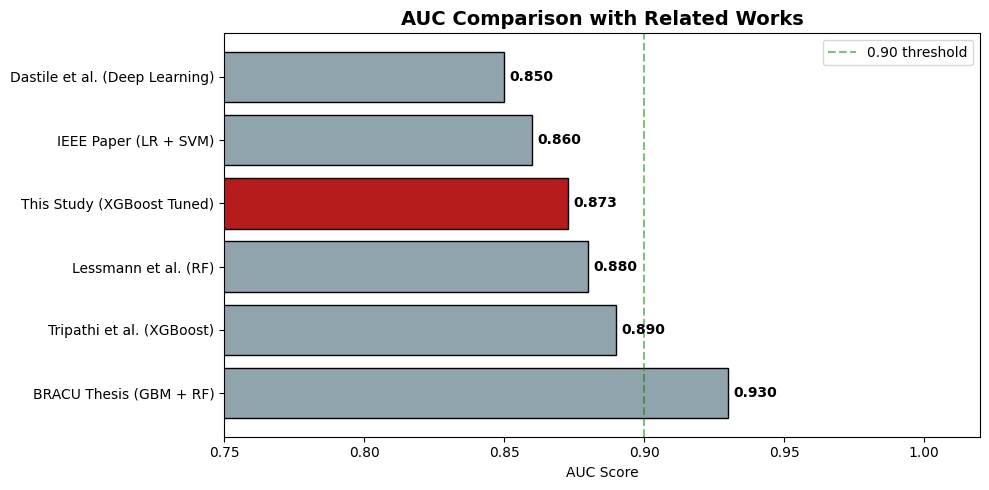

✅ Saved: figures/related_papers_comparison.png


In [11]:
best_auc = tuned_df.iloc[0]['AUC']

related = pd.DataFrame([
    {'Reference': 'This Study (XGBoost Tuned)',     'AUC': best_auc, 'Year': 2026},
    {'Reference': 'BRACU Thesis (GBM + RF)',         'AUC': 0.930,   'Year': 2019},
    {'Reference': 'Tripathi et al. (XGBoost)',       'AUC': 0.890,   'Year': 2022},
    {'Reference': 'Lessmann et al. (RF)',            'AUC': 0.880,   'Year': 2015},
    {'Reference': 'IEEE Paper (LR + SVM)',           'AUC': 0.860,   'Year': 2021},
    {'Reference': 'Dastile et al. (Deep Learning)',  'AUC': 0.850,   'Year': 2020},
]).sort_values('AUC', ascending=False)

related.to_csv('../outputs/related_papers_comparison.csv', index=False)
print(related.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#B71C1C' if 'This Study' in r else '#90A4AE' for r in related['Reference']]
bars = ax.barh(related['Reference'], related['AUC'], color=colors, edgecolor='black')
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0.75, 1.02)
ax.set_title('AUC Comparison with Related Works', fontsize=14, fontweight='bold')
ax.set_xlabel('AUC Score')
ax.axvline(x=0.90, color='green', linestyle='--', alpha=0.5, label='0.90 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/related_papers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/related_papers_comparison.png')

## 🔟 Best Params Summary

In [12]:
print('===== BEST HYPERPARAMETERS =====')
for name, params in best_params_all.items():
    print(f'\n{name}:')
    for k, v in params.items():
        print(f'   {k}: {v}')

===== BEST HYPERPARAMETERS =====

Logistic Regression:
   C: 0.01
   penalty: l2
   solver: liblinear

Random Forest:
   max_depth: 10
   max_features: log2
   min_samples_split: 10
   n_estimators: 500

Gradient Boosting:
   learning_rate: 0.05
   max_depth: 4
   min_samples_split: 5
   n_estimators: 300
   subsample: 0.8

XGBoost:
   colsample_bytree: 0.7
   gamma: 0
   learning_rate: 0.05
   max_depth: 3
   min_child_weight: 5
   n_estimators: 300
   subsample: 0.8


## 1️⃣1️⃣ Final Summary

In [13]:
print('='*65)
print('      NOTEBOOK 02 COMPLETE — TUNING RESULTS')
print('='*65)
print(tuned_df[['Model','AUC','Accuracy','F1-Score','Best CV AUC']].to_string(index=False))
print('='*65)
print(f'\n🏆 Best Tuned Model : {tuned_df.iloc[0]["Model"]}')
print(f'   AUC             : {tuned_df.iloc[0]["AUC"]}')
print(f'   F1-Score        : {tuned_df.iloc[0]["F1-Score"]}')
print('\n📂 Saved:')
print('   outputs/tuned_results.csv')
print('   outputs/baseline_vs_tuned.csv')
print('   models/best_credit_model.pkl')
print('   figures/tuning_auc_comparison.png')
print('   figures/best_model_roc_curve.png')
print('\n➡️  Next: Run 03_shap_deployment.ipynb')

      NOTEBOOK 02 COMPLETE — TUNING RESULTS
              Model    AUC  Accuracy  F1-Score  Best CV AUC
            XGBoost 0.8728    0.7982    0.8449       0.8644
  Gradient Boosting 0.8719    0.9374    0.9225       0.8634
      Random Forest 0.8690    0.8373    0.8709       0.8592
Logistic Regression 0.8679    0.7862    0.8366       0.8587

🏆 Best Tuned Model : XGBoost
   AUC             : 0.8728
   F1-Score        : 0.8449

📂 Saved:
   outputs/tuned_results.csv
   outputs/baseline_vs_tuned.csv
   models/best_credit_model.pkl
   figures/tuning_auc_comparison.png
   figures/best_model_roc_curve.png

➡️  Next: Run 03_shap_deployment.ipynb
